# Importing libraries

In [70]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import StratifiedKFold, cross_val_score, cross_val_predict, cross_validate
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

In [79]:
import warnings
warnings.filterwarnings("ignore", category=FutureWarning)


# Importing our dataset

In [3]:
df = pd.read_csv('diabetes_clean.csv')
print(df.head())


   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35      125  33.6   
1            1       85             66             29      125  26.6   
2            8      183             64             29      125  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


# Feature Preparation

In [4]:
X = df.drop('Outcome', axis=1)
y = df['Outcome']

print(df.shape)
print(y.value_counts())

(768, 9)
Outcome
0    500
1    268
Name: count, dtype: int64


In [5]:
print(X)

     Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0              6      148             72             35      125  33.6   
1              1       85             66             29      125  26.6   
2              8      183             64             29      125  23.3   
3              1       89             66             23       94  28.1   
4              0      137             40             35      168  43.1   
..           ...      ...            ...            ...      ...   ...   
763           10      101             76             48      180  32.9   
764            2      122             70             27      125  36.8   
765            5      121             72             23      112  26.2   
766            1      126             60             29      125  30.1   
767            1       93             70             31      125  30.4   

     DiabetesPedigreeFunction  Age  
0                       0.627   50  
1                       0.351   31  


# Stratified 5-Fold Cross-Validation Setup

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [7]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [8]:
lr_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(random_state=42,max_iter=1000))
])

print(lr_pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', LogisticRegression(max_iter=1000, random_state=42))])


In [9]:
accuracy_scores = cross_val_score(lr_pipeline,X,y,cv=skf,scoring='accuracy')
recall_scores = cross_val_score(lr_pipeline,X,y,cv=skf,scoring='recall')
precision_scores = cross_val_score(lr_pipeline,X,y,cv=skf,scoring='precision')
f1_scores = cross_val_score(lr_pipeline,X,y,cv=skf,scoring='f1')
roc_auc_scores = cross_val_score(lr_pipeline,X,y,cv=skf,scoring='roc_auc')

print("Accuracy for each fold:", accuracy_scores)
print("Recall for each fold:", recall_scores)
print("Precision for each fold:", precision_scores)
print("F1-score for each fold:", f1_scores)
print("ROC-AUC for each fold:", roc_auc_scores)


Accuracy for each fold: [0.77272727 0.7987013  0.77922078 0.75163399 0.76470588]
Recall for each fold: [0.57407407 0.53703704 0.55555556 0.52830189 0.66037736]
Precision for each fold: [0.72093023 0.82857143 0.75       0.68292683 0.66037736]
F1-score for each fold: [0.63917526 0.65168539 0.63829787 0.59574468 0.66037736]
ROC-AUC for each fold: [0.82481481 0.86722222 0.85166667 0.82924528 0.80981132]


In [10]:
joblib.dump(lr_pipeline, 'models/logistic_regression.pkl')
print("Logistic Regression saved successfully!")


Logistic Regression saved successfully!


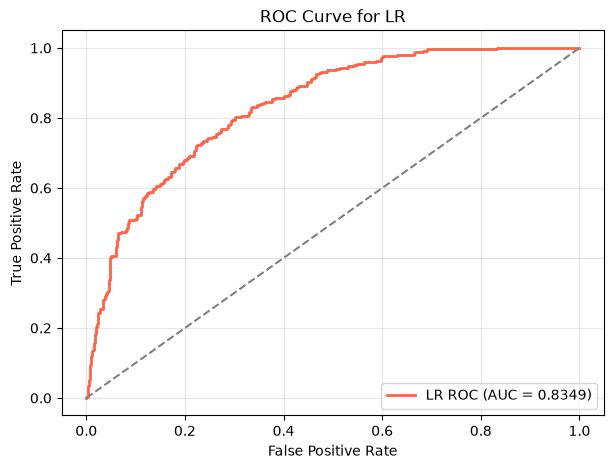

In [11]:
from sklearn.metrics import roc_curve, auc
from sklearn.model_selection import cross_val_predict

lr_proba = cross_val_predict(lr_pipeline, X, y, cv=skf, method='predict_proba')[:,1]
fpr, tpr, _ = roc_curve(y, lr_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'LR ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for LR')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

Text(0.5, 1.0, 'Logistic Regression Confusion Matrix')

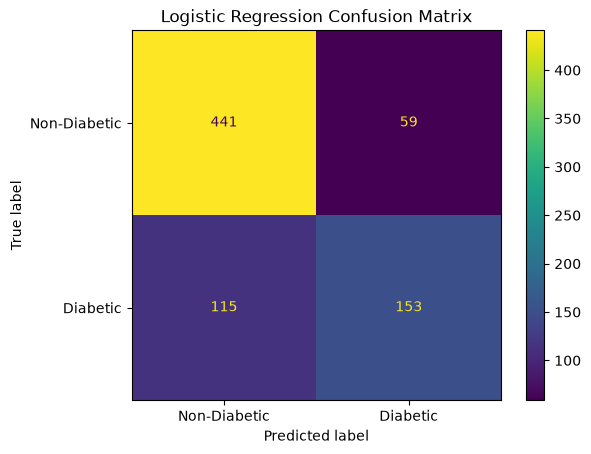

In [12]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

y_pred = cross_val_predict(lr_pipeline,X,y,cv=skf)

cm = confusion_matrix(y, y_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Non-Diabetic', 'Diabetic'])

disp.plot()
plt.title('Logistic Regression Confusion Matrix')

In [13]:
print("\n===== Logistic Regression Tree Summary =====")

print(f"Accuracy : {accuracy_scores.mean():.4f} ± {accuracy_scores.std():.4f}")
print(f"Recall   : {recall_scores.mean():.4f} ± {recall_scores.std():.4f}")
print(f"Precision: {precision_scores.mean():.4f} ± {precision_scores.std():.4f}")
print(f"F1-Score : {f1_scores.mean():.4f} ± {f1_scores.std():.4f}")
print(f"ROC-AUC  : {roc_auc_scores.mean():.4f} ± {roc_auc_scores.std():.4f}")


===== Logistic Regression Tree Summary =====
Accuracy : 0.7734 ± 0.0156
Recall   : 0.5711 ± 0.0474
Precision: 0.7286 ± 0.0587
F1-Score : 0.6371 ± 0.0222
ROC-AUC  : 0.8366 ± 0.0204


# Decision Tree model

In [14]:
from sklearn.tree import DecisionTreeClassifier
dt_model = DecisionTreeClassifier(random_state=42,max_depth=5)
print(dt_model)

DecisionTreeClassifier(max_depth=5, random_state=42)


In [15]:
dt_accuracy = cross_val_score(dt_model,X,y,cv=skf,scoring='accuracy')
dt_recall = cross_val_score(dt_model,X,y,cv=skf,scoring='recall')
dt_precision = cross_val_score(dt_model,X,y,cv=skf,scoring='precision')
dt_f1 = cross_val_score(dt_model,X,y,cv=skf,scoring='f1')
dt_auc = cross_val_score(dt_model,X,y,cv=skf,scoring='roc_auc')

print("Accuracy:", dt_accuracy)
print("Recall:", dt_recall)
print("Precision:", dt_precision)
print("F1:", dt_f1)
print("ROC-AUC:", dt_auc)

Accuracy: [0.76623377 0.73376623 0.73376623 0.67973856 0.64052288]
Recall: [0.64814815 0.59259259 0.53703704 0.28301887 0.73584906]
Precision: [0.67307692 0.62745098 0.64444444 0.57692308 0.4875    ]
F1: [0.66037736 0.60952381 0.58585859 0.37974684 0.58646617]
ROC-AUC: [0.82018519 0.78787037 0.75240741 0.71660377 0.69849057]


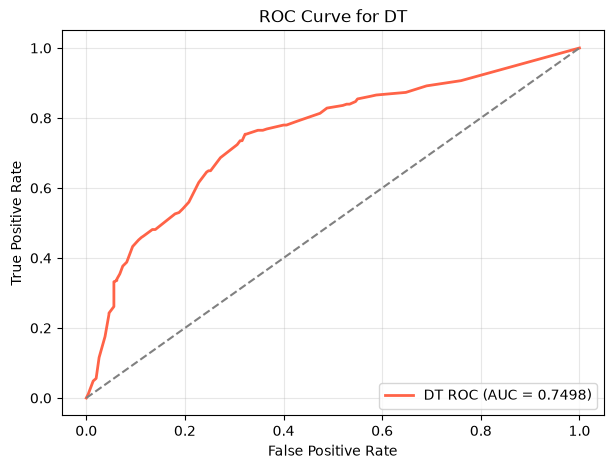

In [16]:
dt_proba = cross_val_predict(dt_model, X, y, cv=skf, method='predict_proba')[:,1]
fpr, tpr, _ = roc_curve(y, dt_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'DT ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for DT')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [17]:
joblib.dump(dt_model, 'models/decision_tree.pkl')
print("Decision Tree saved successfully!")

Decision Tree saved successfully!


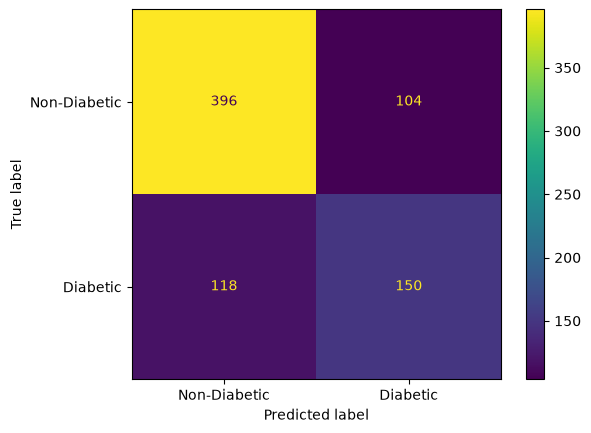

In [18]:
dt_pred = cross_val_predict(dt_model,X,y,cv=skf)
cm = confusion_matrix(y, dt_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot()

In [19]:
print("\n===== Decision Tree Summary =====")

print(f"Accuracy : {dt_accuracy.mean():.4f} ± {dt_accuracy.std():.4f}")
print(f"Recall   : {dt_recall.mean():.4f} ± {dt_recall.std():.4f}")
print(f"Precision: {dt_precision.mean():.4f} ± {dt_precision.std():.4f}")
print(f"F1-Score : {dt_f1.mean():.4f} ± {dt_f1.std():.4f}")
print(f"ROC-AUC  : {dt_auc.mean():.4f} ± {dt_auc.std():.4f}")


===== Decision Tree Summary =====
Accuracy : 0.7108 ± 0.0448
Recall   : 0.5593 ± 0.1530
Precision: 0.6019 ± 0.0652
F1-Score : 0.5644 ± 0.0962
ROC-AUC  : 0.7551 ± 0.0447


# Random Forest

In [20]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=200,random_state=42,max_depth=5)
print(rf_model)

RandomForestClassifier(max_depth=5, n_estimators=200, random_state=42)


In [21]:
rf_accuracy = cross_val_score(rf_model,X,y,cv=skf,scoring='accuracy')
rf_recall = cross_val_score(rf_model,X,y,cv=skf,scoring='recall')
rf_precision = cross_val_score(rf_model,X,y,cv=skf,scoring='precision')
rf_f1 = cross_val_score(rf_model,X,y,cv=skf,scoring='f1')
rf_auc = cross_val_score(rf_model,X,y,cv=skf,scoring='roc_auc')

print("Accuracy:", rf_accuracy)
print("Recall:", rf_recall)
print("Precision:", rf_precision)
print("F1:", rf_f1)
print("ROC-AUC:", rf_auc)

Accuracy: [0.77272727 0.77922078 0.79220779 0.71895425 0.74509804]
Recall: [0.57407407 0.53703704 0.57407407 0.45283019 0.64150943]
Precision: [0.72093023 0.76315789 0.775      0.63157895 0.62962963]
F1: [0.63917526 0.63043478 0.65957447 0.52747253 0.63551402]
ROC-AUC: [0.8637037  0.85685185 0.84148148 0.82207547 0.80679245]


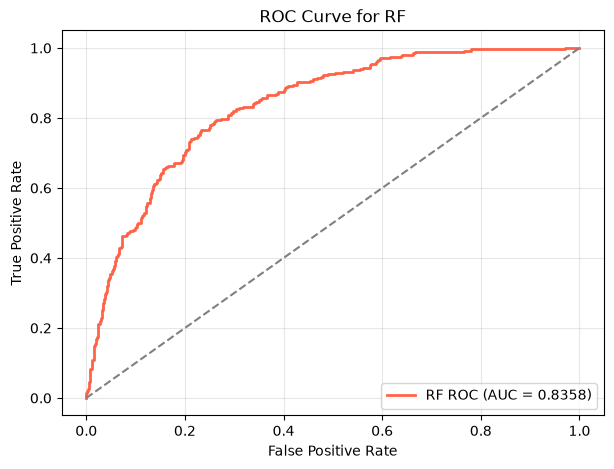

In [22]:
rf_proba = cross_val_predict(rf_model, X, y, cv=skf, method='predict_proba')[:,1]
fpr, tpr, _ = roc_curve(y, rf_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'RF ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for RF')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [23]:
joblib.dump(rf_model, 'models/random_forest.pkl')

['models/random_forest.pkl']

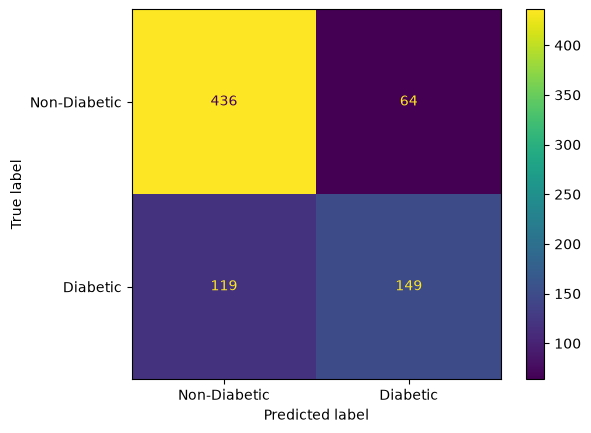

In [24]:
rf_pred = cross_val_predict(rf_model,X,y,cv=skf)
rf_cm = confusion_matrix(y, rf_pred)

disp = ConfusionMatrixDisplay(confusion_matrix=rf_cm,display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot()

In [25]:
print("\n===== Random Forest Summary =====")

print(f"Accuracy : {rf_accuracy.mean():.4f} ± {rf_accuracy.std():.4f}")
print(f"Recall   : {rf_recall.mean():.4f} ± {rf_recall.std():.4f}")
print(f"Precision: {rf_precision.mean():.4f} ± {rf_precision.std():.4f}")
print(f"F1-Score : {rf_f1.mean():.4f} ± {rf_f1.std():.4f}")
print(f"ROC-AUC  : {rf_auc.mean():.4f} ± {rf_auc.std():.4f}")


===== Random Forest Summary =====
Accuracy : 0.7616 ± 0.0263
Recall   : 0.5559 ± 0.0616
Precision: 0.7041 ± 0.0626
F1-Score : 0.6184 ± 0.0465
ROC-AUC  : 0.8382 ± 0.0212


# SVM

In [80]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC
svm_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', SVC(kernel='rbf', C=1.0, gamma='scale',random_state=42, probability=True))
])           
print(svm_pipeline)

Pipeline(steps=[('scaler', StandardScaler()),
                ('model', SVC(probability=True, random_state=42))])


In [81]:
svm_accuracy = cross_val_score(svm_pipeline,X,y,cv=skf,scoring='accuracy')
svm_recall = cross_val_score(svm_pipeline,X,y,cv=skf,scoring='recall')
svm_precision = cross_val_score(svm_pipeline,X,y,cv=skf,scoring='precision')
svm_f1 = cross_val_score(svm_pipeline,X,y,cv=skf,scoring='f1')

svm_auc = cross_val_score(svm_pipeline, X, y, cv=skf, scoring='roc_auc')


print("Accuracy:", svm_accuracy)
print("Recall:", svm_recall)
print("Precision:", svm_precision)
print("F1:", svm_f1)

print("ROC-AUC:", svm_auc)

Accuracy: [0.73376623 0.78571429 0.77922078 0.73856209 0.75163399]
Recall: [0.53703704 0.57407407 0.53703704 0.50943396 0.58490566]
Precision: [0.64444444 0.75609756 0.76315789 0.65853659 0.65957447]
F1: [0.58585859 0.65263158 0.63043478 0.57446809 0.62      ]
ROC-AUC: [0.82333333 0.84240741 0.81944444 0.81471698 0.80660377]


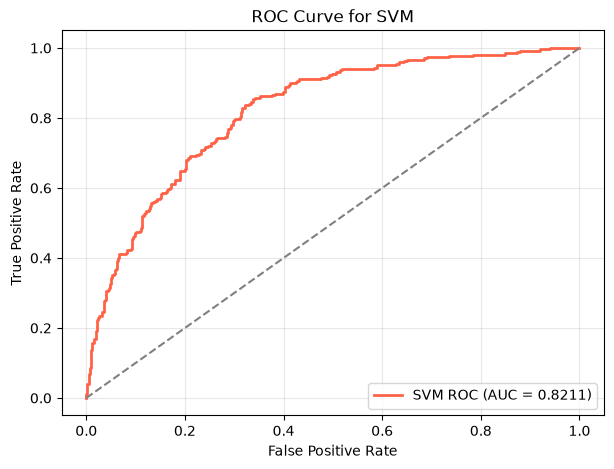

In [82]:
svm_proba = cross_val_predict(svm_pipeline, X, y, cv=skf, method='predict_proba')[:,1]
fpr, tpr, _ = roc_curve(y, svm_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'SVM ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for SVM')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [83]:
joblib.dump(svm_pipeline, 'models/svm.pkl')

['models/svm.pkl']

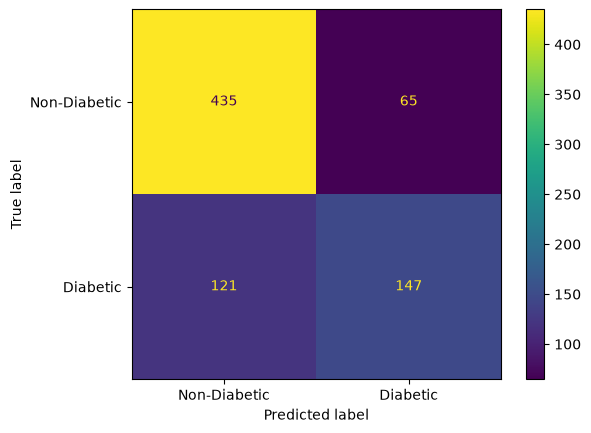

In [84]:
svm_pred = cross_val_predict(svm_pipeline,X,y,cv=skf)
svm_cm = confusion_matrix(y, svm_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=svm_cm,display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot()

In [85]:
print("\n===== SVM Summary =====")

print(f"Accuracy : {svm_accuracy.mean():.4f} ± {svm_accuracy.std():.4f}")
print(f"Recall   : {svm_recall.mean():.4f} ± {svm_recall.std():.4f}")
print(f"Precision: {svm_precision.mean():.4f} ± {svm_precision.std():.4f}")
print(f"F1-Score : {svm_f1.mean():.4f} ± {svm_f1.std():.4f}")
print(f"ROC-AUC  : {svm_auc.mean():.4f} ± {svm_auc.std():.4f}")


===== SVM Summary =====
Accuracy : 0.7578 ± 0.0211
Recall   : 0.5485 ± 0.0275
Precision: 0.6964 ± 0.0520
F1-Score : 0.6127 ± 0.0288
ROC-AUC  : 0.8213 ± 0.0119


# Catboost

In [32]:
from catboost import CatBoostClassifier
cb_model = CatBoostClassifier(iterations=300,learning_rate=0.05,depth=6,l2_leaf_reg=3,random_seed=42,verbose=0)
print(cb_model)

CatBoostClassifier(depth=6, iterations=300, l2_leaf_reg=3, learning_rate=0.05, random_seed=42, verbose=0)


In [34]:
cb_accuracy = cross_val_score(cb_model,X,y,cv=skf,scoring='accuracy')
cb_recall = cross_val_score(cb_model,X,y,cv=skf,scoring='recall')
cb_precision = cross_val_score(cb_model,X,y,cv=skf,scoring='precision')
cb_f1 = cross_val_score(cb_model,X,y,cv=skf,scoring='f1')
cb_auc = cross_val_score(cb_model,X,y,cv=skf,scoring='roc_auc')

print("Accuracy:", cb_accuracy)
print("Recall:", cb_recall)
print("Precision:", cb_precision)
print("F1:", cb_f1)
print("ROC-AUC:", cb_auc)

Accuracy: [0.77922078 0.76623377 0.77272727 0.75163399 0.74509804]
Recall: [0.68518519 0.57407407 0.64814815 0.60377358 0.58490566]
Precision: [0.68518519 0.70454545 0.68627451 0.65306122 0.64583333]
F1: [0.68518519 0.63265306 0.66666667 0.62745098 0.61386139]
ROC-AUC: [0.84537037 0.83981481 0.82333333 0.82396226 0.7845283 ]


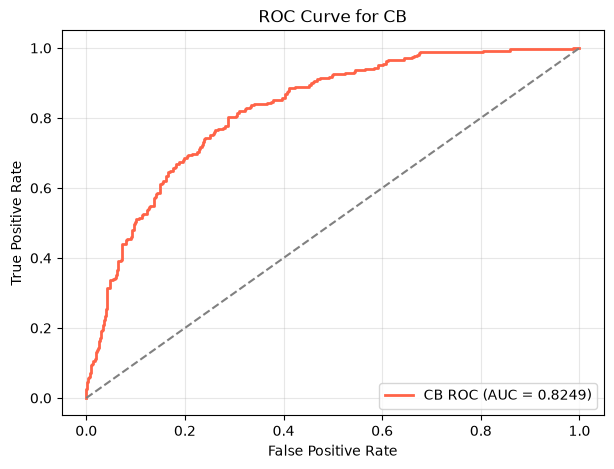

In [37]:
cb_proba = cross_val_predict(cb_model, X, y, cv=skf, method='predict_proba')[:,1]
fpr, tpr, _ = roc_curve(y, cb_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr, color='tomato', lw=2, label=f'CB ROC (AUC = {roc_auc:.4f})')
plt.plot([0,1],[0,1], color='gray', linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve for CB')
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.show()

In [86]:
joblib.dump(cb_model, 'models/catmodel.pkl')

['models/catmodel.pkl']

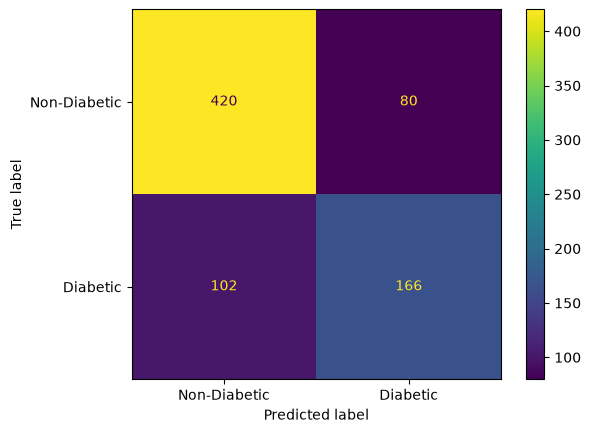

In [89]:
cb_pred = cross_val_predict(cb_model,X,y,cv=skf)
cb_cm = confusion_matrix(y, cb_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cb_cm,display_labels=['Non-Diabetic', 'Diabetic'])
disp.plot()

In [90]:
print("\n===== CatBoost Summary =====")

print(f"Accuracy : {cb_accuracy.mean():.4f} ± {cb_accuracy.std():.4f}")
print(f"Recall   : {cb_recall.mean():.4f} ± {cb_recall.std():.4f}")
print(f"Precision: {cb_precision.mean():.4f} ± {cb_precision.std():.4f}")
print(f"F1-Score : {cb_f1.mean():.4f} ± {cb_f1.std():.4f}")
print(f"ROC-AUC  : {cb_auc.mean():.4f} ± {cb_auc.std():.4f}")


===== CatBoost Summary =====
Accuracy : 0.7630 ± 0.0128
Recall   : 0.6192 ± 0.0416
Precision: 0.6750 ± 0.0221
F1-Score : 0.6452 ± 0.0265
ROC-AUC  : 0.8234 ± 0.0213


# Model Comparison


## Load Saved Models

In [91]:
lr_pipeline = joblib.load("models/logistic_regression.pkl")
dt_model    = joblib.load("models/decision_tree.pkl")
rf_model    = joblib.load("models/random_forest.pkl")
svm_model   = joblib.load("models/svm.pkl")
cb_model    = joblib.load("models/catmodel.pkl")

In [92]:
models = {
    "Logistic Regression": lr_pipeline,
    "Decision Tree": dt_model,
    "Random Forest": rf_model,
    "SVM": svm_model,
    "CatBoost": cb_model
}

In [93]:
skf = StratifiedKFold(n_splits=5,shuffle=True,random_state=42)

In [94]:
results = []

for name, model in models.items():

    scores = cross_validate(model, X,y,cv=skf,
    scoring=[ 'accuracy','recall','precision','f1','roc_auc']
    )

    results.append({
        'Model'    : name,
        'Accuracy' : scores['test_accuracy'].mean(),
        'Recall'   : scores['test_recall'].mean(),
        'Precision': scores['test_precision'].mean(),
        'F1-Score' : scores['test_f1'].mean(),
        'ROC-AUC'  : scores['test_roc_auc'].mean()
    })

    comparison_df = pd.DataFrame(results)

comparison_df = comparison_df.sort_values(
    by='F1-Score',
    ascending=False
)

comparison_df = comparison_df.round(4)

comparison_df

,Model,Accuracy,Recall,Precision,F1-Score,ROC-AUC
4,CatBoost,0.7630,0.6192,0.6750,0.6452,0.8234
0,Logistic Regression,0.7734,0.5711,0.7286,0.6371,0.8366
2,Random Forest,0.7616,0.5559,0.7041,0.6184,0.8382
3,SVM,0.7578,0.5485,0.6964,0.6127,0.8213
1,Decision Tree,0.7108,0.5593,0.6019,0.5644,0.7551


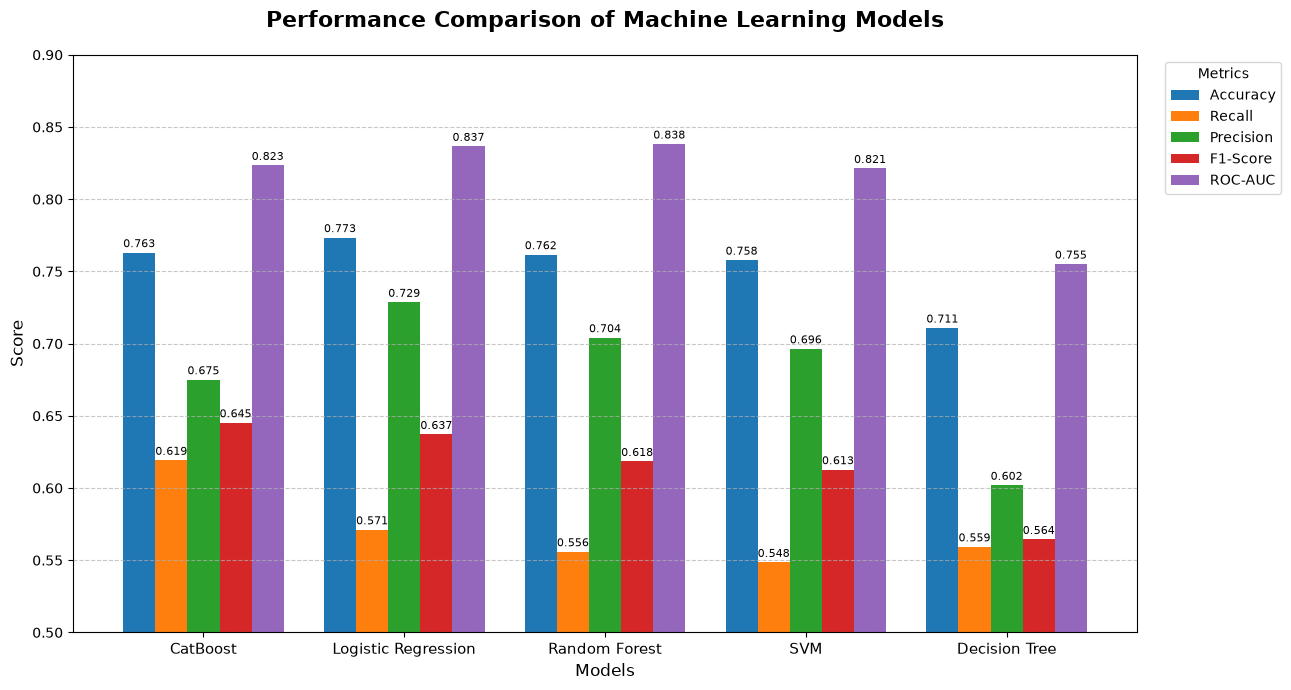

In [95]:
metrics = ['Accuracy', 'Recall', 'Precision', 'F1-Score', 'ROC-AUC']

plot_df = comparison_df.set_index('Model')[metrics]

ax = plot_df.plot(
    kind='bar',
    figsize=(13, 7),
    width=0.8
)

plt.title('Performance Comparison of Machine Learning Models',fontsize=16,fontweight='bold',pad=20)

plt.ylabel('Score', fontsize=12)
plt.xlabel('Models', fontsize=12)

plt.ylim(0.50, 0.90)


plt.grid(axis='y',linestyle='--',alpha=0.7)

plt.xticks(rotation=0, fontsize=11)
plt.yticks(np.arange(0.50, 0.91, 0.05))


for container in ax.containers:
    ax.bar_label(container,fmt='%.3f',fontsize=8,padding=2)


plt.legend(title='Metrics',bbox_to_anchor=(1.02, 1),loc='upper left')

plt.tight_layout()

plt.show()

## Model Selection — CatBoost

Although Random Forest achieves the highest ROC-AUC (0.8382), 
CatBoost is selected as the final model because:

- **Highest Recall (0.619)** — critical in medical diagnosis; 
  missing a diabetic patient is far more costly than a false alarm
- **Highest F1-Score (0.645)** — best balance of precision and recall
- **Most stable** — lowest accuracy variance (±0.0128) across folds
- Built-in robustness to outliers and class imbalance

CatBoost proceeds to `catboost_final.ipynb` for deep analysis